In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
# from matplotlib.colors import ListedColormap5
import ast
import numpy as np
import os
import subprocess
import time
import plotly.express as px
from utils import *

%matplotlib inline

In [3]:
# Constants
MIN_5 = 320
MIN_10 = 620
MIN_15 = 1000
MIN_30 = 1820
MIN_60 = 3620
MIN_120 = 7220

COLLOR_PALLET = {
            'Other human': '#2986cc', # BLUE
            'Electro-mechanical': '#cc0000', # RED
            'Voice': '#6aa84f', #  green 6aa84f
            'Motorised transport': '#ffa500', # orange
            'Geonature': '#8e7cc3', # PURPLE
            'Animal': '#9b5f00', # BROWN
            'Music': '#d172a4', # PINK
            'Background': '#000000', # BLACK
            'Other Sounds': '#c9d631', # yellow
            'Social/communal': '#d8cbf8', # Light purple
            'Human movement': '#40b674', # light green 40b674
        }

def extract_location(file_path):
    file_name = os.path.basename(file_path)
    # print(f"File name: {file_name}")
    # Split the file name by the underscore
    file_name = file_name.split("_")[2]
    # print(f"File name after split: {file_name}")
    return file_name

def remove_label(classes_list, label):
    return [x for x in classes_list if x != label]

def change_label(classes_list, label, new_label):
    return [new_label if x == label else x for x in classes_list]

def first_element(classes_list):
    return [classes_list[0]] if classes_list else []

def interval_printing(average_interval):
    if average_interval > 0 and average_interval < MIN_5:
        print(f"The average interval between each audio file is 5 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_5 and average_interval < MIN_10:
        print(f"The average interval between each audio file is 10 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_10 and average_interval < MIN_15:
        print(f"The average interval between each audio file is 15 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_15 and average_interval < MIN_30:
        print(f"The average interval between each audio file is 30 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_30 and average_interval < MIN_60:
        print(f"The average interval between each audio file is 60 minutes ({round(average_interval)} seconds), which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_60 and average_interval < MIN_120:
        print(f"The average interval between each audio file is 120 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")

def insert_dates(df):
    df["year"] = df.index.year
    df["month"] = df.index.month
    df["day"] = df.index.day
    df["hour"] = df.index.hour
    df["minute"] = df.index.minute
    df["second"] = df.index.second
    df["weekday"] = df.index.day_name()

    weekday_translation = {
        "Monday": " Lunes",
        "Tuesday": " Martes",
        "Wednesday": " Miércoles",
        "Thursday": " Jueves",
        "Friday": " Viernes",
        "Saturday": " Sábado",
        "Sunday": " Domingo"
    }
    df["weekday"] = df["weekday"].replace(weekday_translation)
    df["weekday"] = df["weekday"].astype(str)
    df["day"] = df["day"].astype(str).str.zfill(2)
    df["fullday"] = df["day"] + df["weekday"]
    return df

def output_dir(path: str):
    # get the abs path and remove the last element
    path = os.path.abspath(path).split("\\")[:-2]
    path = "/".join(path)
    
    visualization_dir = path + "/Visualizations"
    os.makedirs(visualization_dir, exist_ok=True)
    
    return visualization_dir

# get the last git tag version
def list_git_tags():
    try:
        tags = tags = subprocess.check_output(["git", "tag"]).strip().decode()
        return tags.split('\n')
    except subprocess.CalledProcessError:
        return None
    
def select_tag(tags):
    for i, tag in enumerate(tags):
        print(f"{i}: {tag}")
    choice = int(input("Select the tag to use: "))
    tag_selected = tags[choice]
    # replace "." with "_" to be able to use it as a file name
    tag_selected = tag_selected.replace(".", "_")
        
    return tag_selected

def get_stable_version():
    tags = list_git_tags()
    # get the latest stable version
    tag_selected = tags[-1]
    print(f"Latest stable version: {tag_selected}")
    # replace "." with "_" to be able to use it as a file name
    tag_selected = tag_selected.replace(".", "_")
    
    print(f"Latest stable version: {tag_selected}")
    
    return tag_selected

print(get_stable_version())
stable_version = get_stable_version()

Latest stable version: v1.1
Latest stable version: v1_1
v1_1
Latest stable version: v1.1
Latest stable version: v1_1


In [4]:
yamnet_classes_path = r"C:\Users\scjaa\Documents\GitHubRepos\AAC\AI_Model\Urban_Model\yamnet_class_map.csv"
yamnet_classes_df = pd.read_csv(yamnet_classes_path)
yamnet_classes = yamnet_classes_df['display_name'].unique()

csv_pred_path = input("Enter the path to the csv file: ")

# clean the csv_pred_path from " and "
csv_pred_path = csv_pred_path.replace('"', '')

# make visualization directory
visualization_dir = output_dir(csv_pred_path)

# get the csv
df = pd.read_csv(csv_pred_path, converters={'class': eval})

# get the location
title = extract_location(csv_pred_path)

# remove nan
df = df.dropna()
df['date'] = pd.to_datetime(df['date'])
# sort by date
df = df.sort_values(by='date')

df

,filename,date,class,probability
0,20231205_111755.WAV,2023-12-05 11:17:55,"[Wind, Vehicle]","['0.2523', '0.1878']"
1,20231205_111755.WAV,2023-12-05 11:17:56,"[Speech, Wind]","['0.4391', '0.0889']"
2,20231205_111755.WAV,2023-12-05 11:17:57,"[Speech, Domestic animals, pets]","['0.3575', '0.0992']"
3,20231205_111755.WAV,2023-12-05 11:17:58,"[Speech, Coin (dropping)]","['0.7361', '0.1419']"
4,20231205_111755.WAV,2023-12-05 11:17:59,"[Speech, Camera]","['0.2200', '0.1746']"
...,...,...,...,...
257969,20231211_111825.WAV,2023-12-11 11:21:24,"[Bicycle, Vehicle]","['0.2244', '0.1948']"
257970,20231211_111825.WAV,2023-12-11 11:21:25,"[Explosion, Gunshot, gunfire]","['0.1820', '0.1399']"
257971,20231211_111825.WAV,2023-12-11 11:21:26,"[Spray, Vehicle]","['0.0645', '0.0642']"
257972,20231211_111825.WAV,2023-12-11 11:21:27,"[Speech, Zipper (clothing)]","['0.4944', '0.0589']"


In [5]:
# df['date'] = pd.to_datetime(df['date'])
time_difference_seconds = df['date'].diff().dt.total_seconds()
average_interval = time_difference_seconds.mean()
print(f"Average interval between each audio file: {average_interval} seconds")
interval_printing(average_interval)

Average interval between each audio file: 2.010338291216523 seconds
The average interval between each audio file is 5 minutes (2 seconds, which are 0 minutes)


In [6]:
df.set_index('date',inplace=True)
df = df.explode('class')
df['display_name'] = df['class']
df['number'] = 1

df_exploded = insert_dates(df)
urban_taxonomy_map = pd.read_json("urban_taxonomy_map_v1_0.json", typ='series').to_dict()
df_exploded['mapped_class'] = df_exploded['class'].map(urban_taxonomy_map)

In [7]:
df_exploded = insert_dates(df)

urban_taxonomy_map = pd.read_json("urban_taxonomy_map_v1_0.json", typ='series').to_dict()
df_exploded['mapped_class'] = df_exploded['class'].map(urban_taxonomy_map)
df_exploded

,filename,class,probability,display_name,number,year,month,day,hour,minute,second,weekday,fullday,mapped_class
date,,,,,,,,,,,,,,
2023-12-05 11:17:55,20231205_111755.WAV,Wind,"['0.2523', '0.1878']",Wind,1,2023,12,05,11,17,55,Martes,05 Martes,Geonature
2023-12-05 11:17:55,20231205_111755.WAV,Vehicle,"['0.2523', '0.1878']",Vehicle,1,2023,12,05,11,17,55,Martes,05 Martes,Motorised transport
2023-12-05 11:17:56,20231205_111755.WAV,Speech,"['0.4391', '0.0889']",Speech,1,2023,12,05,11,17,56,Martes,05 Martes,Voice
2023-12-05 11:17:56,20231205_111755.WAV,Wind,"['0.4391', '0.0889']",Wind,1,2023,12,05,11,17,56,Martes,05 Martes,Geonature
2023-12-05 11:17:57,20231205_111755.WAV,Speech,"['0.3575', '0.0992']",Speech,1,2023,12,05,11,17,57,Martes,05 Martes,Voice
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-11 11:21:26,20231211_111825.WAV,Vehicle,"['0.0645', '0.0642']",Vehicle,1,2023,12,11,11,21,26,Lunes,11 Lunes,Motorised transport
2023-12-11 11:21:27,20231211_111825.WAV,Speech,"['0.4944', '0.0589']",Speech,1,2023,12,11,11,21,27,Lunes,11 Lunes,Voice
2023-12-11 11:21:27,20231211_111825.WAV,Zipper (clothing),"['0.4944', '0.0589']",Zipper (clothing),1,2023,12,11,11,21,27,Lunes,11 Lunes,Social/communal


In [8]:
# convert string to list
# df['class'] = df['class'].apply(ast.literal_eval)

print(f"Type of the column: \t\t {type(df['class'])}")
print(f"Type of the first element: \t\t {type(df['class'][0])}")

# remove labels
# df['class'] = df['class'].apply(lambda x: remove_label(x, 'Nature'))
# df['class'] = df['class'].apply(lambda x: remove_label(x, 'Animal'))

# change labels
# df['class'] = df['class'].apply(lambda x: change_label(x, 'Animal', 'Other Sounds'))
# df['class'] = df['class'].apply(lambda x: change_label(x, 'Other human', 'Other Sounds'))

Type of the column: 		 <class 'pandas.core.series.Series'>
Type of the first element: 		 <class 'str'>


C:\Users\scjaa\AppData\Local\Temp\ipykernel_20760\2125061872.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Type of the first element: \t\t {type(df['class'][0])}")


In [9]:
print(f"These are the class count:\n\n{df_exploded['class'].value_counts()}")
print(f"\nThese are the class summed: \t\t {df_exploded['class'].value_counts().sum()}")
print(f"This is the lenght of the dataframe \t {len(df_exploded)}")

These are the class count:

class
Speech                           130627
Vehicle                          114994
Inside, small room                63596
Silence                           25492
Narration, monologue              23744
                                  ...  
Shatter                               1
Medium engine (mid frequency)         1
Subway, metro, underground            1
Heavy engine (low frequency)          1
Spray                                 1
Name: count, Length: 282, dtype: int64

These are the class summed: 		 515948
This is the lenght of the dataframe 	 515948


In [10]:
df_exploded = df_exploded.sort_values(by=["year", "month", "fullday"])

# map class to number
class_to_num = {class_name: index+1 for index, class_name in enumerate(df_exploded['mapped_class'].unique())}
df_exploded['class_num'] = df_exploded['mapped_class'].map(class_to_num)

# inverting the dictionary to get the name of the class for the legend
name_class = {v: k for k, v in class_to_num.items()}

# mapping from classes numbers to colors
num_to_color = {num: COLLOR_PALLET[class_name] for class_name, num in class_to_num.items()}
cmap = [num_to_color[cls_num] for cls_num in name_class.keys()]

# leggend elements colors
legend_elements = [Patch(facecolor=num_to_color[cls_num], label=f"Clase {cls_num} - {name_class.get(cls_num, '')}") for cls_num in name_class.keys()]

day_class = pd.pivot_table(data=df_exploded, columns=df_exploded.index.time, index=["year", "month", "fullday"], values="class_num", aggfunc='mean')

plt.figure(figsize=(45, 35))

if day_class.isna().all().all() or day_class.empty:
    print("No valid data. Skipping...")
    
else:
    ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False)
    
    ax.set_xticks(range(len(day_class.columns)))
    ax.set_xticklabels([t.strftime('%H:%M:%S') for t in day_class.columns], rotation=90)
    
    yticklabels = [f"{idx[0]}-{idx[1]}-{idx[2]}" for idx in day_class.index]
    ax.set_yticklabels(yticklabels, rotation=0)
    
    plt.legend(handles=legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"{title} | Clases por día y hora")
    plt.plot()

    # plt.savefig(f"{visualization_dir}/{title}_predictions_map_{stable_version}.png", bbox_inches='tight')
    # print(f"Saved image at {visualization_dir}/{title}_predictions_map_{stable_version}.png")

plt.show()

# Stack Bar Plotting

In [11]:
df_exploded['display_name'] = df_exploded['class']

# read ontology union file
union = pd.read_csv(r"C:\Users\scjaa\AAC - CENTRO DE ACUSTICA APLICADA, S.L\I + D + i - Documentos\Modelos_IA\AAC_IA_Urbano\Taxonomia\yamnet_class_AAC_301123.csv",sep=';')

# merge classes with ontology
df_exploded = df_exploded.merge(
    union,
    how='left',
    on='display_name'
    )


# remove Unnamed columns
df_exploded = df_exploded.loc[:, ~df_exploded.columns.str.contains('^Unnamed')]
df_exploded

,filename,class,probability,display_name,number,year,month,day,hour,minute,second,weekday,fullday,mapped_class,index,mid,iso_taxonomy,Brown_Level_1,Brown_Level_2,Brown_Level_3
0,20231205_111755.WAV,Wind,"['0.2523', '0.1878']",Wind,1,2023,12,05,11,17,55,Martes,05 Martes,Geonature,277,/m/03m9d0z,Wind,NaN,Geonature,wind
1,20231205_111755.WAV,Vehicle,"['0.2523', '0.1878']",Vehicle,1,2023,12,05,11,17,55,Martes,05 Martes,Motorised transport,294,/m/07yv9,Roadway traffic,NaN,Motorised transport,roadway traffic
2,20231205_111755.WAV,Speech,"['0.4391', '0.0889']",Speech,1,2023,12,05,11,17,56,Martes,05 Martes,Voice,0,/m/09x0r,Voice,NaN,Voice,speech
3,20231205_111755.WAV,Wind,"['0.4391', '0.0889']",Wind,1,2023,12,05,11,17,56,Martes,05 Martes,Geonature,277,/m/03m9d0z,Wind,NaN,Geonature,wind
4,20231205_111755.WAV,Speech,"['0.3575', '0.0992']",Speech,1,2023,12,05,11,17,57,Martes,05 Martes,Voice,0,/m/09x0r,Voice,NaN,Voice,speech
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515943,20231211_111825.WAV,Vehicle,"['0.0645', '0.0642']",Vehicle,1,2023,12,11,11,21,26,Lunes,11 Lunes,Motorised transport,294,/m/07yv9,Roadway traffic,NaN,Motorised transport,roadway traffic
515944,20231211_111825.WAV,Speech,"['0.4944', '0.0589']",Speech,1,2023,12,11,11,21,27,Lunes,11 Lunes,Voice,0,/m/09x0r,Voice,NaN,Voice,speech
515945,20231211_111825.WAV,Zipper (clothing),"['0.4944', '0.0589']",Zipper (clothing),1,2023,12,11,11,21,27,Lunes,11 Lunes,Social/communal,372,/m/01s0vc,Domestic,NaN,Social/communal,domestic
515946,20231211_111825.WAV,Speech,"['0.9302', '0.0255']",Speech,1,2023,12,11,11,21,28,Lunes,11 Lunes,Voice,0,/m/09x0r,Voice,NaN,Voice,speech


In [12]:
# rename columns
df_exploded.rename(columns={"fullday": "Día", "hour": "Hora", "mid": "Distribución de clases"}, inplace=True)
unique_día_weekday = df_exploded['Día'].unique()

df_exploded['Día'] = pd.Categorical(df_exploded['Día'], categories=unique_día_weekday, ordered=True)
df_exploded.columns

Index(['filename', 'class', 'probability', 'display_name', 'number', 'year',
       'month', 'day', 'Hora', 'minute', 'second', 'weekday', 'Día',
       'mapped_class', 'index', 'Distribución de clases', 'iso_taxonomy',
       'Brown_Level_1', 'Brown_Level_2', 'Brown_Level_3'],
      dtype='object')

In [13]:
dfg = df_exploded.groupby(['Brown_Level_2','Día']).count().reset_index()

fig = px.bar(
    dfg, 
    x='Día',
    y='Distribución de clases',
    color='Brown_Level_2',
    title=f'{title} | Clases por día',
    color_discrete_sequence=px.colors.qualitative.Alphabet, 
    color_discrete_map=COLLOR_PALLET,
    height=900,
    width=2000
)

fig.show()

# save plot
# fig.write_image(f"{visualization_dir}/{title}_classes_per_day_{stable_version}.png")
print(f"Image was saved in {visualization_dir}/{title}_classes_per_day_{stable_version}.png")

C:\Users\scjaa\AppData\Local\Temp\ipykernel_20760\1192662208.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfg = df_exploded.groupby(['Brown_Level_2','Día']).count().reset_index()


Image was saved in //192.168.205.117/AAC_Server/OCIO/OCIO_BILBAO/CAMPAÑA_5/5-Resultados/P1_FA5AAD/AI_MODEL/Visualizations/P1_classes_per_day_v1_1.png


# 15 minutes resamply

In [14]:
df

,filename,class,probability,display_name,number,year,month,day,hour,minute,second,weekday,fullday,mapped_class
date,,,,,,,,,,,,,,
2023-12-05 11:17:55,20231205_111755.WAV,Wind,"['0.2523', '0.1878']",Wind,1,2023,12,05,11,17,55,Martes,05 Martes,Geonature
2023-12-05 11:17:55,20231205_111755.WAV,Vehicle,"['0.2523', '0.1878']",Vehicle,1,2023,12,05,11,17,55,Martes,05 Martes,Motorised transport
2023-12-05 11:17:56,20231205_111755.WAV,Speech,"['0.4391', '0.0889']",Speech,1,2023,12,05,11,17,56,Martes,05 Martes,Voice
2023-12-05 11:17:56,20231205_111755.WAV,Wind,"['0.4391', '0.0889']",Wind,1,2023,12,05,11,17,56,Martes,05 Martes,Geonature
2023-12-05 11:17:57,20231205_111755.WAV,Speech,"['0.3575', '0.0992']",Speech,1,2023,12,05,11,17,57,Martes,05 Martes,Voice
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-11 11:21:26,20231211_111825.WAV,Vehicle,"['0.0645', '0.0642']",Vehicle,1,2023,12,11,11,21,26,Lunes,11 Lunes,Motorised transport
2023-12-11 11:21:27,20231211_111825.WAV,Speech,"['0.4944', '0.0589']",Speech,1,2023,12,11,11,21,27,Lunes,11 Lunes,Voice
2023-12-11 11:21:27,20231211_111825.WAV,Zipper (clothing),"['0.4944', '0.0589']",Zipper (clothing),1,2023,12,11,11,21,27,Lunes,11 Lunes,Social/communal


In [15]:
resampled_df = df.resample('15min').agg({
    'filename': 'first',  # Taking the first filename in each bin
    'class': 'first',  # Taking the first class in each bin
    'probability': 'first',  # Custom handling might be needed
    'display_name': 'first',  # Taking the first display name in each bin
    'number': 'sum',  # Summing up the numbers in each bin
    'year': 'first',
    'month': 'first',
    'day': 'first',
    'hour': 'first',
    'minute': 'first',
    'second': 'first',
    'weekday': 'first',
    'fullday': 'first',
    'mapped_class': 'first'
})

resampled_df

,filename,class,probability,display_name,number,year,month,day,hour,minute,second,weekday,fullday,mapped_class
date,,,,,,,,,,,,,,
2023-12-05 11:15:00,20231205_111755.WAV,Wind,"['0.2523', '0.1878']",Wind,926,2023,12,05,11,17,55,Martes,05 Martes,Geonature
2023-12-05 11:30:00,20231205_113330.WAV,Vehicle,"['0.2101', '0.0966']",Vehicle,900,2023,12,05,11,33,30,Martes,05 Martes,Motorised transport
2023-12-05 11:45:00,20231205_114835.WAV,Vehicle,"['0.1043', '0.0435']",Vehicle,900,2023,12,05,11,48,35,Martes,05 Martes,Motorised transport
2023-12-05 12:00:00,20231205_120340.WAV,Speech,"['0.2756', '0.1280']",Speech,900,2023,12,05,12,3,40,Martes,05 Martes,Voice
2023-12-05 12:15:00,20231205_121845.WAV,Chant,"['0.5556', '0.4110']",Chant,900,2023,12,05,12,18,45,Martes,05 Martes,Voice
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-11 10:15:00,20231211_101805.WAV,Vehicle,"['0.2363', '0.0817']",Vehicle,900,2023,12,11,10,18,5,Lunes,11 Lunes,Motorised transport
2023-12-11 10:30:00,20231211_103310.WAV,Vehicle,"['0.1319', '0.0669']",Vehicle,900,2023,12,11,10,33,10,Lunes,11 Lunes,Motorised transport
2023-12-11 10:45:00,20231211_104815.WAV,Speech,"['0.1996', '0.0488']",Speech,900,2023,12,11,10,48,15,Lunes,11 Lunes,Voice


In [16]:
resampled_df = resampled_df.explode('class')
# resampled_df['display_name'] = resampled_df['class']
resampled_df['number'] = 1

resampled_df

,filename,class,probability,display_name,number,year,month,day,hour,minute,second,weekday,fullday,mapped_class
date,,,,,,,,,,,,,,
2023-12-05 11:15:00,20231205_111755.WAV,Wind,"['0.2523', '0.1878']",Wind,1,2023,12,05,11,17,55,Martes,05 Martes,Geonature
2023-12-05 11:30:00,20231205_113330.WAV,Vehicle,"['0.2101', '0.0966']",Vehicle,1,2023,12,05,11,33,30,Martes,05 Martes,Motorised transport
2023-12-05 11:45:00,20231205_114835.WAV,Vehicle,"['0.1043', '0.0435']",Vehicle,1,2023,12,05,11,48,35,Martes,05 Martes,Motorised transport
2023-12-05 12:00:00,20231205_120340.WAV,Speech,"['0.2756', '0.1280']",Speech,1,2023,12,05,12,3,40,Martes,05 Martes,Voice
2023-12-05 12:15:00,20231205_121845.WAV,Chant,"['0.5556', '0.4110']",Chant,1,2023,12,05,12,18,45,Martes,05 Martes,Voice
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-11 10:15:00,20231211_101805.WAV,Vehicle,"['0.2363', '0.0817']",Vehicle,1,2023,12,11,10,18,5,Lunes,11 Lunes,Motorised transport
2023-12-11 10:30:00,20231211_103310.WAV,Vehicle,"['0.1319', '0.0669']",Vehicle,1,2023,12,11,10,33,10,Lunes,11 Lunes,Motorised transport
2023-12-11 10:45:00,20231211_104815.WAV,Speech,"['0.1996', '0.0488']",Speech,1,2023,12,11,10,48,15,Lunes,11 Lunes,Voice


Saved image at //192.168.205.117/AAC_Server/OCIO/OCIO_BILBAO/CAMPAÑA_5/5-Resultados/P1_FA5AAD/AI_MODEL/Visualizations/P1_predictions_map_v1_1.png


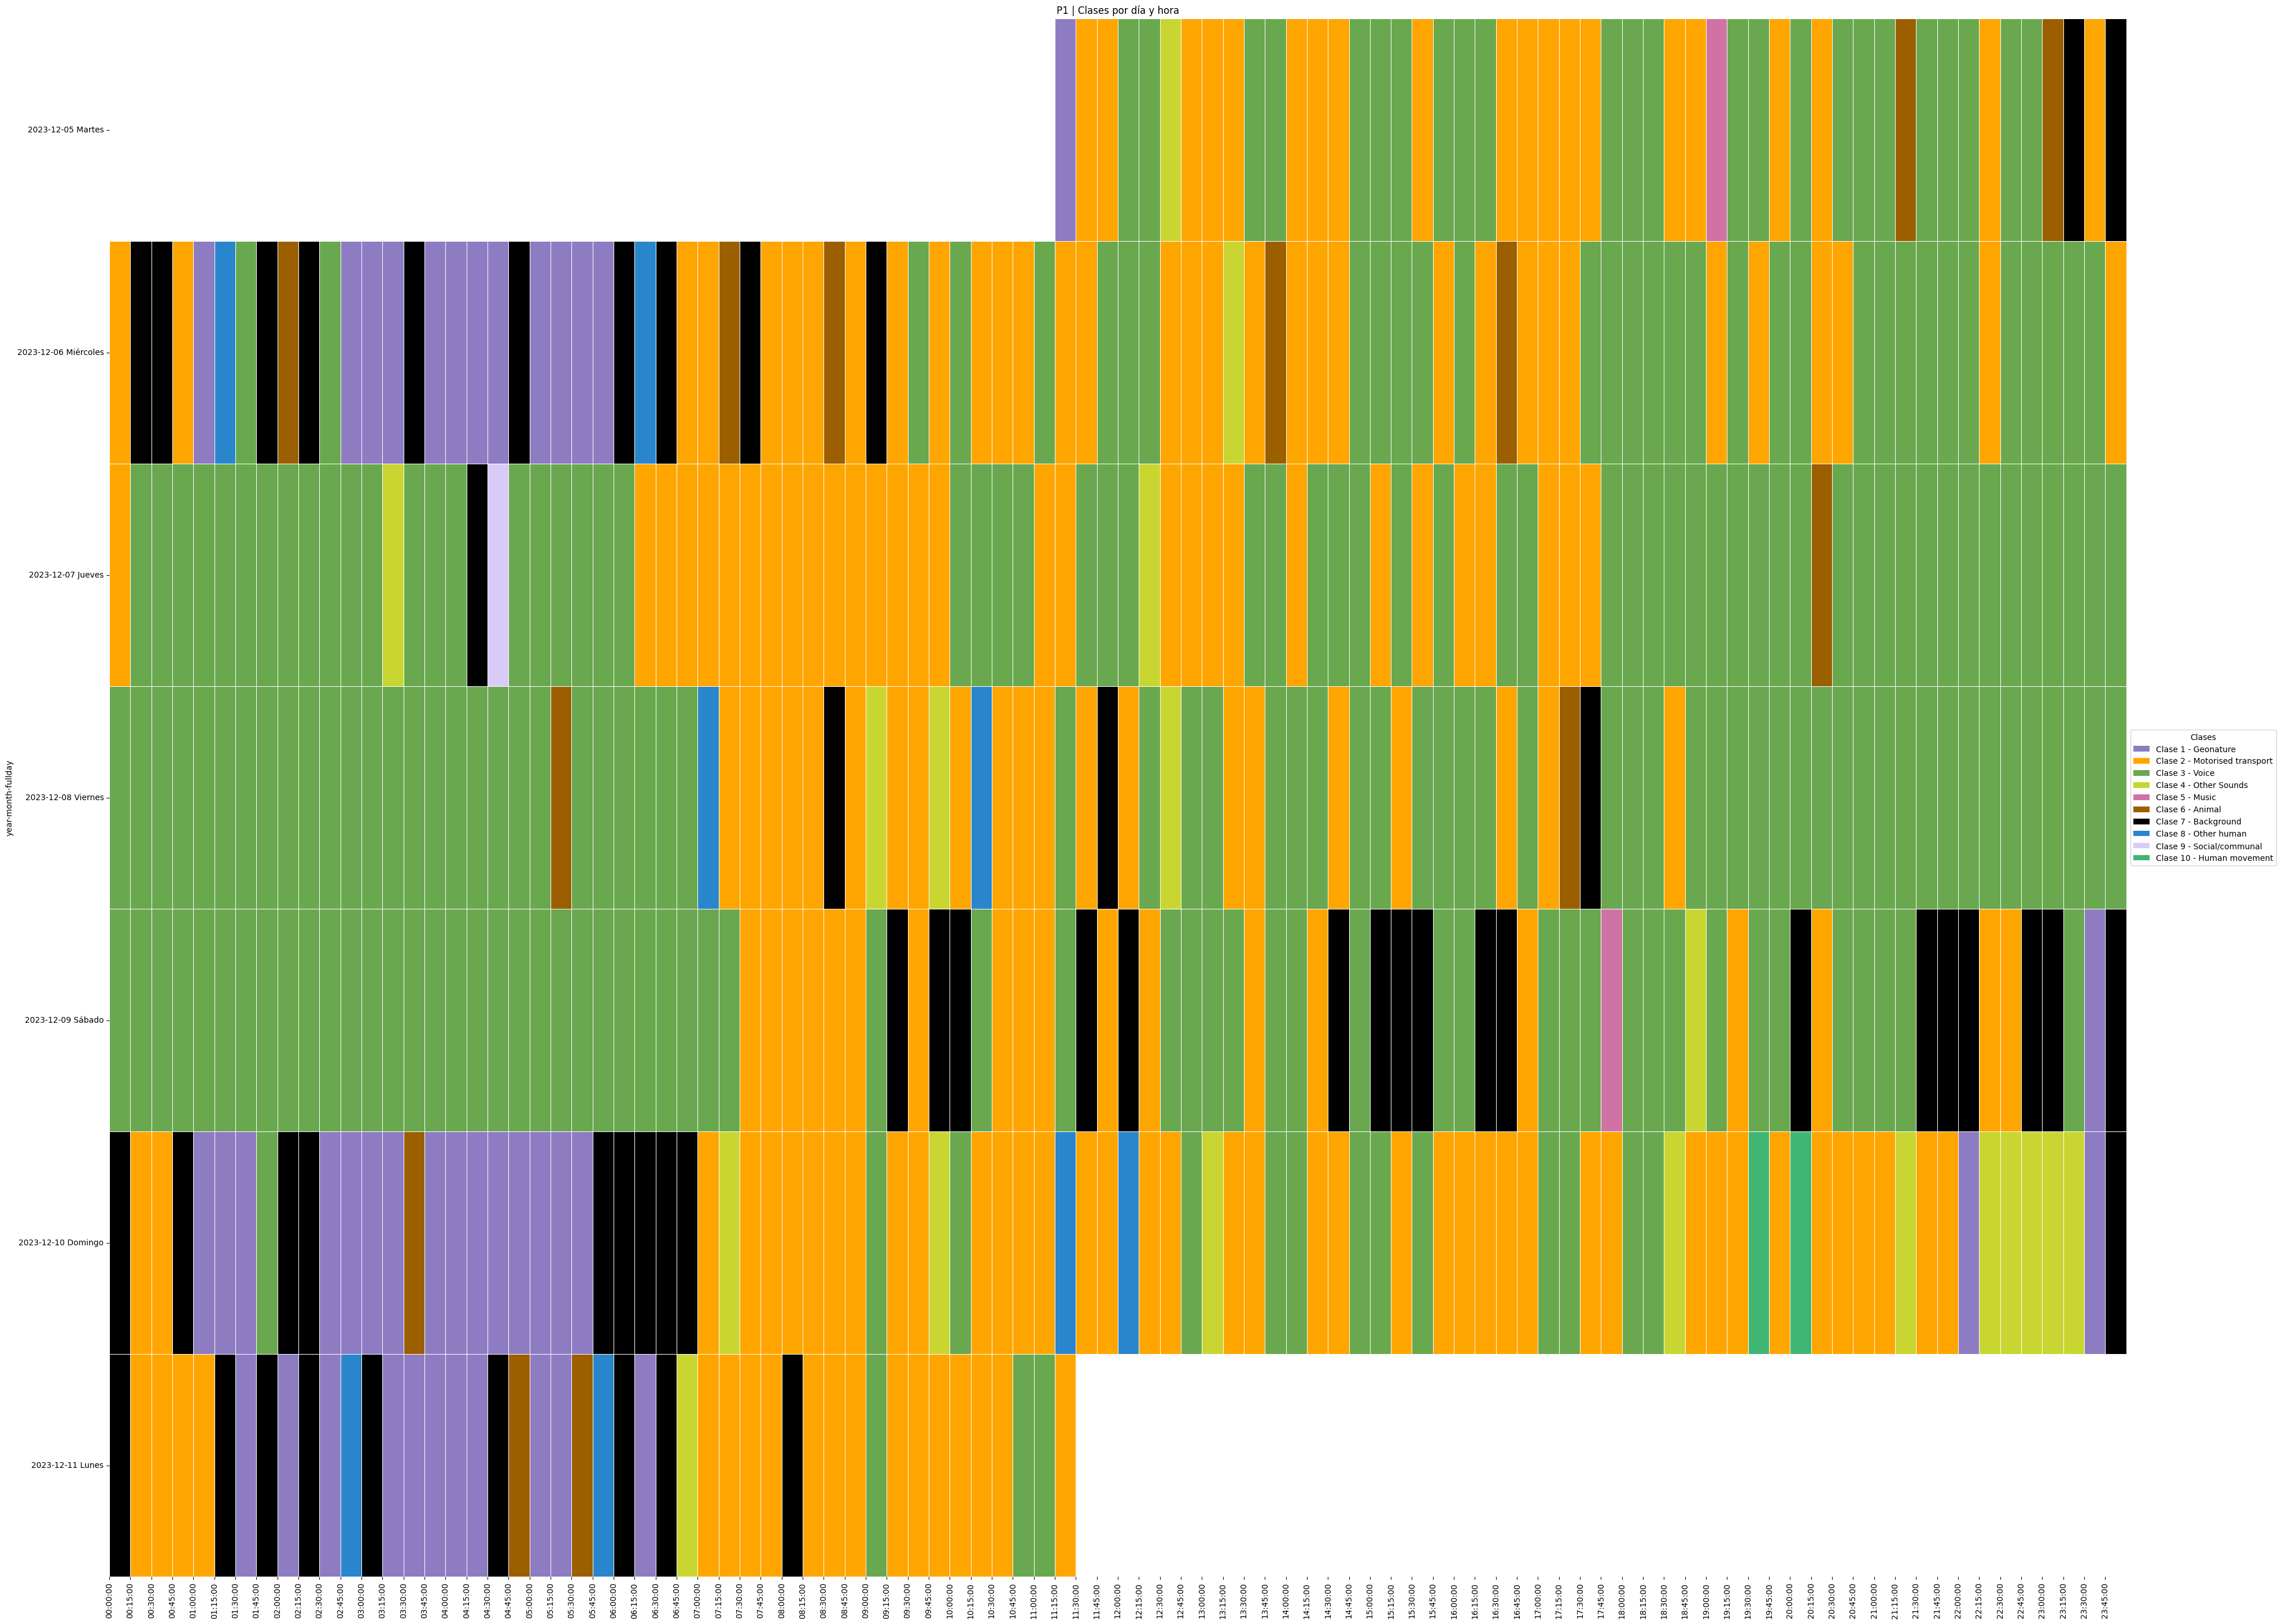

In [17]:
df_resampled = resampled_df.sort_values(by=["year", "month", "fullday"])

# map class to number
class_to_num = {class_name: index+1 for index, class_name in enumerate(df_resampled['mapped_class'].unique())}
df_resampled['class_num'] = df_resampled['mapped_class'].map(class_to_num)

# inverting the dictionary to get the name of the class for the legend
name_class = {v: k for k, v in class_to_num.items()}

# mapping from classes numbers to colors
num_to_color = {num: COLLOR_PALLET[class_name] for class_name, num in class_to_num.items()}
cmap = [num_to_color[cls_num] for cls_num in name_class.keys()]

# leggend elements colors
legend_elements = [Patch(facecolor=num_to_color[cls_num], label=f"Clase {cls_num} - {name_class.get(cls_num, '')}") for cls_num in name_class.keys()]

day_class = pd.pivot_table(data=df_resampled, columns=df_resampled.index.time, index=["year", "month", "fullday"], values="class_num", aggfunc='mean')

plt.figure(figsize=(45, 35))

if day_class.isna().all().all() or day_class.empty:
    print("No valid data. Skipping...")
    
else:
    ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False)
    
    ax.set_xticks(range(len(day_class.columns)))
    ax.set_xticklabels([t.strftime('%H:%M:%S') for t in day_class.columns], rotation=90)
    
    yticklabels = [f"{idx[0]}-{idx[1]}-{idx[2]}" for idx in day_class.index]
    ax.set_yticklabels(yticklabels, rotation=0)
    
    plt.legend(handles=legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"{title} | Clases por día y hora")
    plt.plot()

    # plt.savefig(f"{visualization_dir}/{title}_predictions_map_{stable_version}.png", bbox_inches='tight')
    print(f"Saved image at {visualization_dir}/{title}_predictions_map_{stable_version}.png")

plt.show()